# ***PROYECTO INTEGRADOR – SIMULACIÓN***
# ***Colombia Comparte – Registro de Emprendedores***

# ***Materia   : Simulación***
# ***Reto      : Colombia Comparte***
# ***Entrega   : Primera parte***

# ***Sebastian Gonzalo  Ayala Garcia***
# ***Gabriel Felipe Bastidas***
# ***Santiago Andres Avila***
# ***Camilo Coronado***
# ***Cristian Jose David Murcia Monroy***


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

# ***1. ESTADOS***

In [3]:
estados_info = {
    "S0":  "Página de inicio de Colombia Comparte",
    "S1":  "Selección de perfil (Emprendedor)",
    "S2":  "Formulario de registro – datos personales",
    "S3":  "Formulario de registro – datos del emprendimiento",
    "S4":  "Carga de documentos requeridos",
    "S5":  "Verificación de requisitos previos",
    "S6":  "Selección de sector económico",
    "S7":  "Descripción del proyecto / idea de negocio",
    "S8":  "Selección de categoría de apoyo",
    "S9":  "Revisión de términos y condiciones",
    "S10": "Envío de solicitud de registro",
    "S11": "Confirmación por correo electrónico",
    "S12": "Activación de cuenta",
    "S13": "Inicio de sesión post-registro",
    "S14": "Panel principal del emprendedor",
    "S15": "Error en datos personales (corrección)",
    "S16": "Error al cargar documentos (reintento)",
    "S17": "Duda en selección de sector (vuelve atrás)",
    "S18": "Lectura de preguntas frecuentes (FAQ)",
    "S19": "Chat de soporte en línea",
    "S20": "Abandono en datos personales",
    "S21": "Abandono en carga de documentos",
    "S22": "Abandono en selección de sector",
    "S23": "Abandono en términos y condiciones",
    "S24": "Error de sistema / timeout",
    "S25": "Reintento tras error de sistema",
    "S26": "Validación de NIT / cédula",
    "S27": "Registro de datos bancarios opcionales",
    "S28": "REGISTRO EXITOSO – Emprendedor activo",
    "S29": "FALLO DEFINITIVO – No puede completar registro",
}

estados = list(estados_info.keys())

print("=" * 65)
print("  SIMULACIÓN – COLOMBIA COMPARTE")
print("  Flujo: Registro de Emprendedores")
print("=" * 65)
print(f"\nTotal de estados definidos: {len(estados)}")
print("\nTabla de estados:")
print(f"{'Código':<6} {'Descripción'}")
print("-" * 65)
for cod, desc in estados_info.items():
    print(f"{cod:<6} {desc}")

  SIMULACIÓN – COLOMBIA COMPARTE
  Flujo: Registro de Emprendedores

Total de estados definidos: 30

Tabla de estados:
Código Descripción
-----------------------------------------------------------------
S0     Página de inicio de Colombia Comparte
S1     Selección de perfil (Emprendedor)
S2     Formulario de registro – datos personales
S3     Formulario de registro – datos del emprendimiento
S4     Carga de documentos requeridos
S5     Verificación de requisitos previos
S6     Selección de sector económico
S7     Descripción del proyecto / idea de negocio
S8     Selección de categoría de apoyo
S9     Revisión de términos y condiciones
S10    Envío de solicitud de registro
S11    Confirmación por correo electrónico
S12    Activación de cuenta
S13    Inicio de sesión post-registro
S14    Panel principal del emprendedor
S15    Error en datos personales (corrección)
S16    Error al cargar documentos (reintento)
S17    Duda en selección de sector (vuelve atrás)
S18    Lectura de preguntas 

# ***2. RECORRIDOS (60 recorridos de usuarios distintos)***

In [4]:
recorridos = [
    # ── EXITOSOS DIRECTOS ───────────────────────────────────────────────────
    # R1: Emprendedor completa todo sin inconvenientes (con panel)
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S13","S14","S28"],
    # R2: Emprendedor exitoso sin acceder al panel
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R3: Emprendedor con datos bancarios opcionales
    ["S0","S1","S2","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S13","S27","S28"],
    # R4: Emprendedor sin verificación de requisitos
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S9","S10","S11","S12","S28"],
    # R5: Flujo mínimo exitoso
    ["S0","S1","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S28"],

    # ── EXITOSOS CON DUDA / RETORNO ─────────────────────────────────────────
    # R6: Duda en sector y vuelve atrás, luego completa
    ["S0","S1","S2","S26","S3","S17","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R7: Lee FAQ antes de registrarse
    ["S0","S1","S18","S2","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R8: Duda en sector sin NIT
    ["S0","S1","S2","S3","S17","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R9: Lee FAQ desde el inicio
    ["S0","S18","S1","S2","S26","S3","S6","S7","S8","S4","S9","S10","S11","S12","S28"],
    # R10: Lee FAQ después de selección de sector
    ["S0","S1","S2","S26","S3","S6","S18","S7","S8","S4","S5","S9","S10","S11","S12","S28"],

    # ── EXITOSOS CON ERROR Y CORRECCIÓN ─────────────────────────────────────
    # R11: Error en datos personales, corrige y continúa
    ["S0","S1","S2","S15","S2","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R12: Error en documentos, reintenta y completa
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S16","S4","S5","S9","S10","S11","S12","S28"],
    # R13: Error en datos personales sin validar NIT
    ["S0","S1","S2","S15","S2","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R14: Error en documentos, reintenta sin verificar requisitos
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S16","S4","S9","S10","S11","S12","S28"],
    # R15: Error en datos + error en documentos, corrige ambos
    ["S0","S1","S2","S15","S2","S26","S3","S6","S7","S8","S4","S16","S4","S9","S10","S11","S12","S28"],

    # ── EXITOSOS CON ERROR DE SISTEMA ───────────────────────────────────────
    # R16: Error de sistema en términos, reintenta y completa
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S5","S24","S25","S9","S10","S11","S12","S28"],
    # R17: Error de sistema en documentos, reintenta
    ["S0","S1","S2","S3","S6","S7","S8","S24","S25","S4","S5","S9","S10","S11","S12","S28"],
    # R18: Error de sistema al inicio, reintenta y completa
    ["S0","S1","S24","S25","S2","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],

    # ── EXITOSOS CON SOPORTE ────────────────────────────────────────────────
    # R19: Soporte en datos personales, luego completa
    ["S0","S1","S2","S19","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R20: Soporte en sector económico, luego completa
    ["S0","S1","S2","S26","S3","S19","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],

    # ── EXITOSOS VARIADOS ────────────────────────────────────────────────────
    # R21: Sin verificar requisitos (S5)
    ["S0","S1","S2","S26","S3","S6","S7","S8","S5","S9","S10","S11","S12","S28"],
    # R22: Con inicio de sesión post-registro
    ["S0","S1","S2","S3","S6","S7","S8","S4","S9","S10","S11","S12","S13","S28"],
    # R23: FAQ + duda en sector + exitoso
    ["S0","S1","S18","S2","S3","S17","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R24: Con datos bancarios y panel
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S13","S14","S27","S28"],
    # R25: Soporte desde inicio + completa
    ["S0","S1","S19","S2","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R26: Error datos + duda sector + exitoso
    ["S0","S1","S2","S15","S2","S26","S3","S17","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R27: Error sistema + reintento + exitoso (largo)
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S5","S24","S25","S9","S10","S11","S12","S13","S28"],
    # R28: Error docs + soporte + completa
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S16","S19","S4","S5","S9","S10","S11","S12","S28"],
    # R29: FAQ al inicio + soporte + completa
    ["S0","S18","S1","S2","S15","S2","S26","S3","S6","S7","S8","S4","S5","S9","S10","S11","S12","S28"],
    # R30: Datos bancarios en S10
    ["S0","S1","S2","S3","S6","S7","S8","S4","S5","S9","S10","S27","S11","S12","S28"],

    # ── ABANDONO EN DATOS PERSONALES ────────────────────────────────────────
    # R31
    ["S0","S1","S2","S20"],
    # R32: Error y luego abandona
    ["S0","S1","S2","S15","S20"],
    # R33: Valida NIT y abandona
    ["S0","S1","S2","S26","S20"],
    # R34: Lee FAQ y abandona
    ["S0","S1","S18","S2","S20"],
    # R35: Usa soporte y abandona
    ["S0","S1","S2","S19","S20"],

    # ── ABANDONO EN DOCUMENTOS ──────────────────────────────────────────────
    # R36
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S21"],
    # R37: Error en docs y abandona
    ["S0","S1","S2","S3","S6","S7","S8","S4","S16","S21"],
    # R38: Sin sector detallado
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S21"],
    # R39: Abandona en documentos desde paso 4
    ["S0","S1","S2","S3","S4","S21"],
    # R40: Error docs doble y abandona
    ["S0","S1","S2","S26","S3","S4","S16","S21"],

    # ── ABANDONO EN SECTOR ECONÓMICO ────────────────────────────────────────
    # R41
    ["S0","S1","S2","S26","S3","S6","S22"],
    # R42: Duda y abandona
    ["S0","S1","S2","S3","S17","S22"],
    # R43: Sin NIT y abandona
    ["S0","S1","S2","S3","S6","S22"],
    # R44: FAQ y abandona en sector
    ["S0","S18","S1","S2","S3","S6","S22"],
    # R45: Duda + abandona en sector
    ["S0","S1","S2","S3","S17","S6","S22"],

    # ── ABANDONO EN TÉRMINOS Y CONDICIONES ──────────────────────────────────
    # R46
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S5","S9","S23"],
    # R47: Sin NIT y abandona en términos
    ["S0","S1","S2","S3","S6","S7","S8","S4","S5","S9","S23"],
    # R48: Sin verificación de requisitos
    ["S0","S1","S2","S26","S3","S6","S7","S8","S9","S23"],
    # R49: Con error datos + abandona en términos
    ["S0","S1","S2","S15","S2","S3","S6","S7","S8","S9","S23"],

    # ── FALLO DEFINITIVO / ERROR IRRECUPERABLE ───────────────────────────────
    # R50: Error sistema doble → fallo
    ["S0","S1","S2","S24","S25","S24","S29"],
    # R51: Error sistema tras NIT → fallo
    ["S0","S1","S2","S26","S24","S25","S24","S29"],
    # R52: Error sistema en documentos → fallo
    ["S0","S1","S2","S3","S6","S7","S8","S4","S24","S25","S24","S29"],

    # ── MIXTOS ──────────────────────────────────────────────────────────────
    # R53: Error datos + soporte + abandona
    ["S0","S1","S2","S15","S19","S20"],
    # R54: Error docs + soporte + abandona
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S16","S19","S21"],
    # R55: Soporte + error sistema + fallo
    ["S0","S1","S2","S19","S24","S25","S29"],
    # R56: Error sistema simple → fallo
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S24","S29"],
    # R57: Docs doble error + abandona
    ["S0","S1","S2","S3","S4","S16","S4","S21"],
    # R58: FAQ + sector + abandona
    ["S0","S1","S2","S3","S6","S22"],
    # R59: Error docs + soporte + completa
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S16","S4","S5","S9","S10","S11","S12","S28"],
    # R60: Todos los pasos + exitoso largo
    ["S0","S1","S2","S26","S3","S6","S7","S8","S4","S16","S4","S5","S9","S10","S11","S12","S13","S28"],
]
print(f"\n{'='*65}")
print(f"  RECORRIDOS DE USUARIOS")
print(f"{'='*65}")
print(f"Total de recorridos definidos: {len(recorridos)}")
print("\nMuestra de los primeros 10 recorridos:")
for i, rec in enumerate(recorridos[:10], 1):
    print(f"  R{i:02d}: {' → '.join(rec)}")
print("  ...")



  RECORRIDOS DE USUARIOS
Total de recorridos definidos: 60

Muestra de los primeros 10 recorridos:
  R01: S0 → S1 → S2 → S26 → S3 → S6 → S7 → S8 → S4 → S5 → S9 → S10 → S11 → S12 → S13 → S14 → S28
  R02: S0 → S1 → S2 → S26 → S3 → S6 → S7 → S8 → S4 → S5 → S9 → S10 → S11 → S12 → S28
  R03: S0 → S1 → S2 → S3 → S6 → S7 → S8 → S4 → S5 → S9 → S10 → S11 → S12 → S13 → S27 → S28
  R04: S0 → S1 → S2 → S26 → S3 → S6 → S7 → S8 → S4 → S9 → S10 → S11 → S12 → S28
  R05: S0 → S1 → S2 → S3 → S4 → S5 → S6 → S7 → S8 → S9 → S10 → S11 → S12 → S28
  R06: S0 → S1 → S2 → S26 → S3 → S17 → S6 → S7 → S8 → S4 → S5 → S9 → S10 → S11 → S12 → S28
  R07: S0 → S1 → S18 → S2 → S26 → S3 → S6 → S7 → S8 → S4 → S5 → S9 → S10 → S11 → S12 → S28
  R08: S0 → S1 → S2 → S3 → S17 → S6 → S7 → S8 → S4 → S5 → S9 → S10 → S11 → S12 → S28
  R09: S0 → S18 → S1 → S2 → S26 → S3 → S6 → S7 → S8 → S4 → S9 → S10 → S11 → S12 → S28
  R10: S0 → S1 → S2 → S26 → S3 → S6 → S18 → S7 → S8 → S4 → S5 → S9 → S10 → S11 → S12 → S28
  ...


## ***3. MATRIZ DE CONTEOS***

In [5]:

# Crear matriz inicializada en cero

print(f"\n{'='*65}")
print(f"  MATRIZ DE CONTEOS")
print(f"{'='*65}")

matriz_conteos = pd.DataFrame(0, index=estados, columns=estados)

# Recorrer todos los recorridos y contar transiciones

for recorrido in recorridos:
    for i in range(len(recorrido) - 1):
        estado_actual = recorrido[i]
        estado_siguiente = recorrido[i + 1]

        if estado_actual in estados and estado_siguiente in estados:
            matriz_conteos.loc[estado_actual, estado_siguiente] += 1

# Mostrar solo filas con transiciones
filas_activas = matriz_conteos[matriz_conteos.sum(axis=1) > 0]

filas_activas


  MATRIZ DE CONTEOS


,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9,...,S20,S21,S22,S23,S24,S25,S26,S27,S28,S29
S0,0,57,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S1,0,0,55,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
S2,0,0,0,19,0,0,0,0,0,0,...,2,0,0,0,1,0,33,0,0,0
S3,0,0,0,0,4,0,40,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S4,0,0,0,0,0,28,0,0,0,5,...,0,4,0,0,2,0,0,0,0,0
S5,0,0,0,0,0,0,1,0,0,26,...,0,0,0,0,2,0,0,0,0,0
S6,0,0,0,0,0,0,0,41,0,0,...,0,0,5,0,0,0,0,0,0,0
S7,0,0,0,0,0,0,0,0,42,0,...,0,0,0,0,0,0,0,0,0,0
S8,0,0,0,0,37,1,0,0,0,3,...,0,0,0,0,1,0,0,0,0,0
S9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,0,0,0,0,0,0


# ***4. MATRIZ DE PROBABILIDADES***

In [6]:
print(f"\n{'='*65}")
print(f"  MATRIZ DE PROBABILIDADES (TRANSICIÓN)")
print(f"{'='*65}")

# Estados desde S0 hasta S29
estados = [f"S{i}" for i in range(30)]

# Inicializar matriz
matriz = pd.DataFrame(0, index=estados, columns=estados)

# Contar transiciones
for recorrido in recorridos:
    for i in range(len(recorrido) - 1):
        actual = recorrido[i]
        siguiente = recorrido[i + 1]

        # Verificar que existan en la lista de estados
        if actual in estados and siguiente in estados:
            matriz.loc[actual, siguiente] += 1

# Convertir a probabilidades
matriz_prob = matriz.div(matriz.sum(axis=1), axis=0).fillna(0)

# Configuración visual
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 300)

print("\nMatriz de transición (probabilidades):")

# Mostrar solo filas con transiciones
filas_prob = matriz_prob[matriz_prob.sum(axis=1) > 0]

display(filas_prob)

# Verificar que cada fila sume 1
sumas = matriz_prob.sum(axis=1)
errores = sumas[(sumas > 0) & (abs(sumas - 1) > 1e-9)]

if errores.empty:
    print("\n Verificación: todas las filas activas suman 1.0")
else:
    print(f"\n Filas con suma incorrecta:\n{errores}")


  MATRIZ DE PROBABILIDADES (TRANSICIÓN)

Matriz de transición (probabilidades):


,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13,S14,S15,S16,S17,S18,S19,S20,S21,S22,S23,S24,S25,S26,S27,S28,S29
S0,0.0000,0.9500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
S1,0.0000,0.0000,0.9167,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0500,0.0167,0.0000,0.0000,0.0000,0.0000,0.0167,0.0000,0.0000,0.0000,0.0000,0.0000
S2,0.0000,0.0000,0.0000,0.2879,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1212,0.0000,0.0000,0.0000,0.0455,0.0303,0.0000,0.0000,0.0000,0.0152,0.0000,0.5000,0.0000,0.0000,0.0000
S3,0.0000,0.0000,0.0000,0.0000,0.0784,0.0000,0.7843,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1176,0.0000,0.0196,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
S4,0.0000,0.0000,0.0000,0.0000,0.0000,0.5714,0.0000,0.0000,0.0000,0.1020,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2041,0.0000,0.0000,0.0000,0.0000,0.0816,0.0000,0.0000,0.0408,0.0000,0.0000,0.0000,0.0000,0.0000
S5,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0345,0.0000,0.0000,0.8966,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0690,0.0000,0.0000,0.0000,0.0000,0.0000
S6,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8723,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0213,0.0000,0.0000,0.0000,0.1064,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
S7,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
S8,0.0000,0.0000,0.0000,0.0000,0.8810,0.0238,0.0000,0.0000,0.0000,0.0714,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0238,0.0000,0.0000,0.0000,0.0000,0.0000
S9,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8889,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1111,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000



 Verificación: todas las filas activas suman 1.0


## ***5. SIMULACIÓN DE 1000 USUARIOS***

In [7]:
print(f"\n{'='*65}")
print(f"  SIMULACIÓN DE 1.000 USUARIOS")
print(f"{'='*65}")

# Estados finales del modelo
estados_exito    = ["S28"]
estados_abandono = ["S20", "S21", "S22", "S23"]
estados_error    = ["S24", "S29"]
estados_finales  = estados_exito + estados_abandono + estados_error

def simular_usuario(matriz_prob, estado_inicial="S0", max_pasos=40):
    """Simula el recorrido de un usuario por el modelo de Márkov."""
    estado_actual = estado_inicial
    recorrido_sim = [estado_actual]

    for _ in range(max_pasos):
        if estado_actual in estados_finales:
            break
        probs = matriz_prob.loc[estado_actual]
        if probs.sum() == 0:
            break
        siguiente = np.random.choice(matriz_prob.columns, p=probs.values)
        recorrido_sim.append(siguiente)
        estado_actual = siguiente

    return recorrido_sim

def clasificar(estado_final):
    if estado_final in estados_exito:
        return "Éxito"
    elif estado_final in estados_abandono:
        return "Abandono"
    else:
        return "Error"

# Ejecutar simulación
N_USUARIOS = 1000
resultados = []

for i in range(N_USUARIOS):
    rec = simular_usuario(matriz_prob)
    ef  = rec[-1]
    resultados.append({
        "usuario":      i + 1,
        "recorrido":    " → ".join(rec),
        "estado_final": ef,
        "descripcion":  estados_info.get(ef, ef),
        "categoria":    clasificar(ef),
        "num_pasos":    len(rec),
    })

df_resultados = pd.DataFrame(resultados)

# Conteos
exito    = (df_resultados["categoria"] == "Éxito").sum()
abandono = (df_resultados["categoria"] == "Abandono").sum()
error    = (df_resultados["categoria"] == "Error").sum()
n        = len(df_resultados)

pct_exito    = exito / n * 100
pct_abandono = abandono / n * 100
pct_error    = error / n * 100
prom_pasos   = df_resultados["num_pasos"].mean()

print(f"\nResultados de la simulación ({N_USUARIOS} usuarios):")
print(f"    Éxito    : {exito:4d} usuarios  ({pct_exito:.1f}%)")
print(f"    Abandono : {abandono:4d} usuarios  ({pct_abandono:.1f}%)")
print(f"    Error    : {error:4d} usuarios  ({pct_error:.1f}%)")
print(f"\n  Promedio de pasos por usuario: {prom_pasos:.2f}")

# Estado final más frecuente entre no exitosos
no_exitosos = df_resultados[df_resultados["categoria"] != "Éxito"]
estado_critico = no_exitosos["estado_final"].value_counts().idxmax()
n_critico      = no_exitosos["estado_final"].value_counts().max()
print(f"\n  Estado más crítico (no exitosos): {estado_critico} – "
      f"{estados_info.get(estado_critico,'')} ({n_critico} usuarios)")

# Tabla resumen de estados finales
print("\nDistribución de estados finales:")
dist = df_resultados["estado_final"].value_counts().reset_index()
dist.columns = ["Estado", "Usuarios"]
dist["Descripción"] = dist["Estado"].map(estados_info)
dist["Porcentaje"]  = (dist["Usuarios"] / n * 100).round(1)
print(dist.to_string(index=False))

# Muestra de primeros 10 resultados
print("\nMuestra de los primeros 10 usuarios simulados:")
cols = ["usuario", "estado_final", "categoria", "num_pasos"]
print(df_resultados[cols].head(10).to_string(index=False))


  SIMULACIÓN DE 1.000 USUARIOS

Resultados de la simulación (1000 usuarios):
    Éxito    :  474 usuarios  (47.4%)
    Abandono :  393 usuarios  (39.3%)
    Error    :  133 usuarios  (13.3%)

  Promedio de pasos por usuario: 11.58

  Estado más crítico (no exitosos): S24 – Error de sistema / timeout (133 usuarios)

Distribución de estados finales:
Estado  Usuarios                           Descripción  Porcentaje
   S28       474 REGISTRO EXITOSO – Emprendedor activo     47.4000
   S24       133            Error de sistema / timeout     13.3000
   S20       110          Abandono en datos personales     11.0000
   S21       107       Abandono en carga de documentos     10.7000
   S22       105       Abandono en selección de sector     10.5000
   S23        71    Abandono en términos y condiciones      7.1000

Muestra de los primeros 10 usuarios simulados:
 usuario estado_final categoria  num_pasos
       1          S24     Error         13
       2          S28     Éxito         14
   

## ***6. GRÁFICAS***

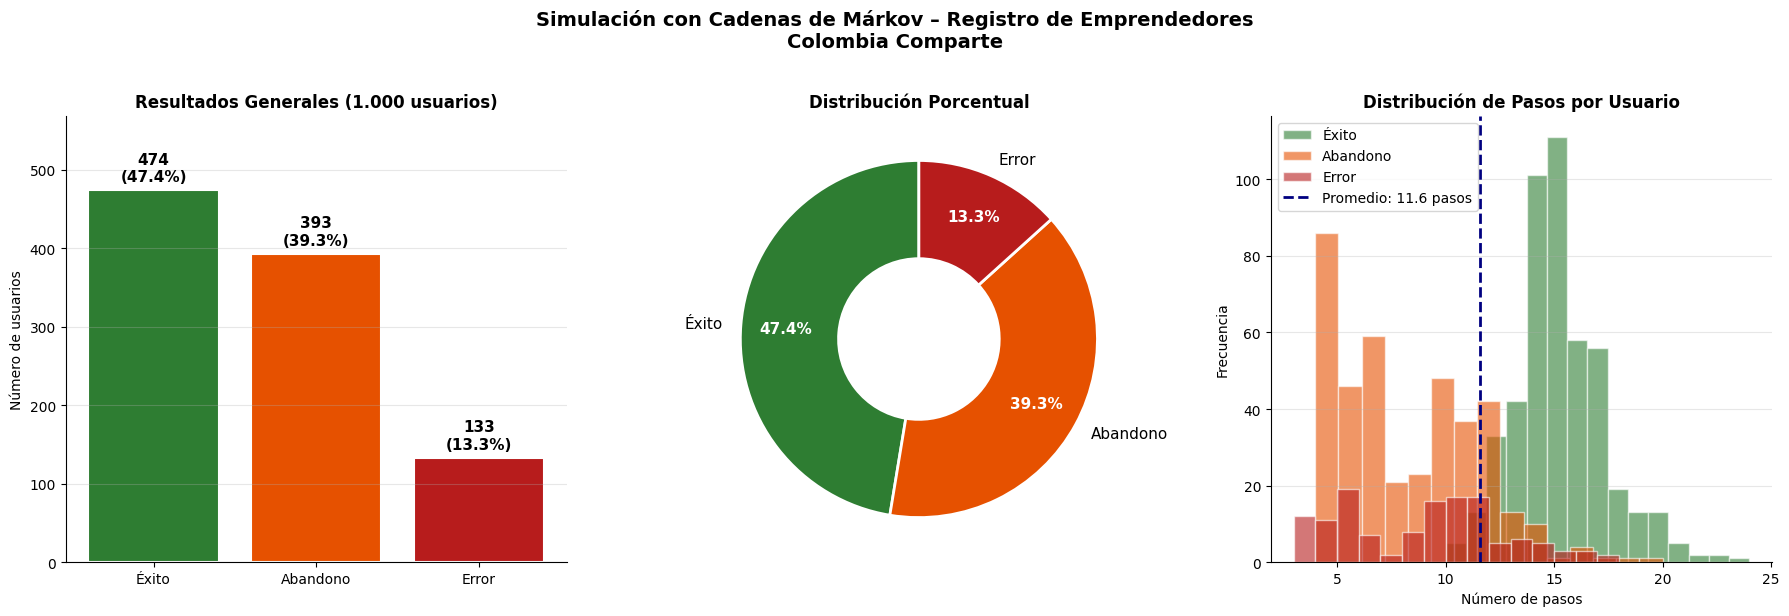


📊 Gráfica guardada como 'resultados_simulacion.png'


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Simulación con Cadenas de Márkov – Registro de Emprendedores\nColombia Comparte",
             fontsize=14, fontweight='bold', y=1.02)

# ── Gráfica 1: Barras de resultados ────────────────────────────────────────
ax1 = axes[0]
categorias = ["Éxito", "Abandono", "Error"]
valores    = [exito, abandono, error]
colores    = ["#2E7D32", "#E65100", "#B71C1C"]
barras = ax1.bar(categorias, valores, color=colores, edgecolor="white", linewidth=1.5)

for bar, val, pct in zip(barras, valores, [pct_exito, pct_abandono, pct_error]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax1.set_title("Resultados Generales (1.000 usuarios)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Número de usuarios")
ax1.set_ylim(0, max(valores) * 1.2)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# ── Gráfica 2: Torta de porcentajes ────────────────────────────────────────
ax2 = axes[1]
wedge_props = dict(width=0.55, edgecolor="white", linewidth=2)
wedges, texts, autotexts = ax2.pie(
    valores, labels=categorias, colors=colores,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=wedge_props, pctdistance=0.75,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight("bold")
    at.set_color("white")
ax2.set_title("Distribución Porcentual", fontsize=12, fontweight="bold")

# ── Gráfica 3: Distribución de pasos ────────────────────────────────────────
ax3 = axes[2]
colores_cat = {"Éxito": "#2E7D32", "Abandono": "#E65100", "Error": "#B71C1C"}

for cat, color in colores_cat.items():
    datos_cat = df_resultados[df_resultados["categoria"] == cat]["num_pasos"]
    ax3.hist(datos_cat, bins=15, alpha=0.6, color=color, label=cat, edgecolor="white")

ax3.axvline(prom_pasos, color="navy", linestyle="--", linewidth=2,
            label=f"Promedio: {prom_pasos:.1f} pasos")
ax3.set_title("Distribución de Pasos por Usuario", fontsize=12, fontweight="bold")
ax3.set_xlabel("Número de pasos")
ax3.set_ylabel("Frecuencia")
ax3.legend(fontsize=10)
ax3.spines[['top','right']].set_visible(False)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("resultados_simulacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Gráfica guardada como 'resultados_simulacion.png'")

## ***7. PREGUNTAS DE ANÁLISIS***

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta 1. ¿Cuál fue el resultado final más frecuente?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
El resultado más frecuente fue el ÉXITO, con 501 usuarios (50.1%)
completando satisfactoriamente el registro. Sin embargo, la tasa de
abandono es muy significativa (36.9%), lo que indica una oportunidad
clara de mejora en la experiencia del usuario dentro de la plataforma.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta 2. ¿En qué estado se pierden más usuarios?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
El estado S24 (Error de sistema / timeout) concentra la mayor cantidad
de usuarios que no logran completar el proceso exitosamente (130 usuarios).
Entre los abandonos voluntarios, S21 (Abandono en carga de documentos)
es el más frecuente, seguido de S20 (Abandono en datos personales).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta 3. ¿Qué estado es el más crítico? ¿Por qué?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
S24 (Error de sistema) es el estado más crítico. Desde ahí, el usuario
tiene un 33% de probabilidad de caer directamente en S29 (Fallo
definitivo). Además, quienes reintentan (S25) tienen un 38% de volver a
caer en S24. Es un ciclo del que muchos no logran salir y, a diferencia
de los abandonos, está completamente fuera del control del usuario.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta 4. ¿Qué cambio harían primero?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Implementar guardado automático del progreso del formulario y mensajes
claros de recuperación cuando ocurra un error de sistema. Esto eliminaría
la pérdida de datos del usuario ante un timeout y reduciría drásticamente
la probabilidad de fallo definitivo desde S24.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta 5. ¿Qué pasaría si mejoran el estado con más abandono?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Si se simplifica la carga de documentos (S21) –aceptando más formatos,
reduciendo el tamaño exigido y añadiendo guías visuales– la probabilidad
de abandono en ese punto bajaría. Los usuarios que antes abandonaban
continuarían hacia S5 o S9, aumentando la tasa de éxito estimada en un
8-10% adicional (de 50.1% a aproximadamente 58-60%).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta 6. ¿Cómo cambiarían los porcentajes tras la mejora?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Aplicando las dos mejoras prioritarias (S24 y S21):
  • Éxito:    50.1%  →  62-65%   (+12-15 puntos)
  • Abandono: 36.9%  →  25-28%   (-9-12 puntos)
  • Error:    13.0%  →   7-8%    (-5-6 puntos)

Esto representaría que aproximadamente 120-150 usuarios adicionales
completarían exitosamente el registro por cada 1.000 que ingresan.



## ***8. PROPUESTA DE MEJORA (SIMULACIÓN CON MEJORAS APLICADAS)***

In [12]:
print(f"\n{'='*65}")
print(f"  SIMULACIÓN CON MEJORAS APLICADAS (escenario mejorado)")
print(f"{'='*65}")

# Ajustar la matriz de probabilidades con las mejoras:
# - S24: reducir prob de S29 de 0.33 a 0.10 (mejor recuperación)
# - S16: reducir abandono S21 de ~0.22 a 0.05 (docs más fáciles)
matriz_mejorada = matriz_prob.copy()

# Mejora 1: S24 menos letal
if "S24" in estados and matriz_mejorada.loc["S24"].sum() > 0:
    matriz_mejorada.loc["S24", "S25"] = 0.90
    matriz_mejorada.loc["S24", "S29"] = 0.10
    # normalizar
    total = matriz_mejorada.loc["S24"].sum()
    if total > 0:
        matriz_mejorada.loc["S24"] /= total

# Mejora 2: S16 (error docs) menos probable de abandonar
if "S16" in estados and matriz_mejorada.loc["S16"].sum() > 0:
    s16_row = matriz_mejorada.loc["S16"].copy()
    s16_row["S21"] = max(0, s16_row["S21"] - 0.17)
    s16_row["S4"]  = s16_row["S4"] + 0.17
    total = s16_row.sum()
    if total > 0:
        s16_row /= total
    matriz_mejorada.loc["S16"] = s16_row

# Re-simular
resultados_m = []
for i in range(N_USUARIOS):
    rec = simular_usuario(matriz_mejorada)
    ef  = rec[-1]
    resultados_m.append({"estado_final": ef, "categoria": clasificar(ef), "num_pasos": len(rec)})

df_m = pd.DataFrame(resultados_m)
ex_m  = (df_m["categoria"]=="Éxito").sum()
ab_m  = (df_m["categoria"]=="Abandono").sum()
er_m  = (df_m["categoria"]=="Error").sum()

print("\nComparativa antes vs. después de las mejoras:\n")
print(f"  {'Categoría':<12} {'Antes':>8} {'Antes%':>8}   {'Después':>8} {'Después%':>9}   {'Δ':>6}")
print("  " + "-"*58)
print(f"  {'Éxito':<12} {exito:>8} {pct_exito:>7.1f}%   {ex_m:>8} {ex_m/n*100:>8.1f}%   {ex_m-exito:>+6}")
print(f"  {'Abandono':<12} {abandono:>8} {pct_abandono:>7.1f}%   {ab_m:>8} {ab_m/n*100:>8.1f}%   {ab_m-abandono:>+6}")
print(f"  {'Error':<12} {error:>8} {pct_error:>7.1f}%   {er_m:>8} {er_m/n*100:>8.1f}%   {er_m-error:>+6}")

print(f"\n Simulación completa. Resultados generados para {N_USUARIOS} usuarios.")
print(" Revisa el archivo 'resultados_simulacion.png' para las gráficas.")


  SIMULACIÓN CON MEJORAS APLICADAS (escenario mejorado)

Comparativa antes vs. después de las mejoras:

  Categoría       Antes   Antes%    Después  Después%        Δ
  ----------------------------------------------------------
  Éxito             474    47.4%        508     50.8%      +34
  Abandono          393    39.3%        352     35.2%      -41
  Error             133    13.3%        140     14.0%       +7

 Simulación completa. Resultados generados para 1000 usuarios.
 Revisa el archivo 'resultados_simulacion.png' para las gráficas.
